# How Fresh Are Your Blueberries? — Article Figures

Companion notebook for the blog post draft. Follows the post's own section order;
every figure the post uses is generated here, inline, from the current codebase —
this notebook is the reproducible source for all of them.


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import wasserstein_distance
from matplotlib.lines import Line2D

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
_wheel_dir = REPO_ROOT / "dist" / "wheel"
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)

FIG_DIR = REPO_ROOT / "notebooks" / "outputs" / "article_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, RED, PURPLE, GREEN = "#4C72B0", "#DD8452", "#C44E52", "#8172B3", "#55A868"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

print("repo:", REPO_ROOT)


repo: /home/oliver/blog/blueberries-voi


### Production run: Modal dispatch

This run uses **30 seeds** (up from the 8-seed smoke scale of the original
version of this notebook) at a longer episode (`n_burn=14, n_score=45`, up from
`2/30`), dispatched to Modal instead of a local process pool, per
`.team/plans/2026-08-29-gsin-belief-accuracy-blog-post.md` §2.4.

**Modal pattern matches `notebooks/12_damped_sw_alpha_bayesian_optimization.ipynb`'s
established, working setup** rather than inventing a new one: same
`uv_sync(frozen=True)`-based image build (local source + data + current
`dist/wheel/*.whl` layered on top), same chunked spawn+get dispatch capped by
`MODAL_CONCURRENCY` (`_evaluate_batch_modal`'s pattern). One deliberate
difference from an earlier draft of this cell: shard functions take every
input as an **explicit argument** (seed, ladder config, episode length,
controller values) rather than closing over notebook-local globals —
matching notebook 12's `soo_shard(job: dict)` convention, which sidesteps any
uncertainty about cloudpickle closure-capture of interactively-defined
functions.

In [2]:
import modal

MODAL_CONCURRENCY = 64
MODAL_FUNCTION_TIMEOUT_S = 600.0

_PKG_SRC = REPO_ROOT / "src" / "blueberries_voi"
_DATA_DIR = REPO_ROOT / "data"
_EXPERIMENTS_DIR = REPO_ROOT / "experiments"
_WHEEL_DIR = Path(os.environ.get("BLUEBERRIES_VOI_WHEEL", REPO_ROOT / "dist" / "wheel"))
if _WHEEL_DIR.is_dir():
    _wheel_files = sorted(_WHEEL_DIR.glob("blueberries_voi_core-*.whl"))
    WHEEL_PATH = _wheel_files[-1] if _wheel_files else (_WHEEL_DIR / "blueberries_voi_core.whl")
else:
    WHEEL_PATH = _WHEEL_DIR
_WHEEL_REMOTE = f"/tmp/{WHEEL_PATH.name}"

_UV_PROJECT_DIR = os.path.relpath(REPO_ROOT, Path.cwd().resolve())
if _UV_PROJECT_DIR == os.curdir:
    _UV_PROJECT_DIR = "."

_thread_env = {
    "PYTHONPATH": "/root",
    "BLUEBERRIES_VOI_BACKEND": "rust",
    "OMP_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
}
_base_image = modal.Image.debian_slim(python_version="3.11").uv_sync(
    uv_project_dir=_UV_PROJECT_DIR, extras=["data"], frozen=True,
)
if modal.is_local():
    modal_image = _base_image.add_local_dir(str(_PKG_SRC), remote_path="/root/blueberries_voi", copy=True)
    modal_image = modal_image.add_local_dir(str(_DATA_DIR), remote_path="/data", copy=True)
    modal_image = modal_image.add_local_dir(str(_EXPERIMENTS_DIR), remote_path="/experiments", copy=True)
    if WHEEL_PATH.is_file():
        modal_image = modal_image.add_local_file(str(WHEEL_PATH), _WHEEL_REMOTE, copy=True)
        modal_image = modal_image.run_commands(f"pip install {_WHEEL_REMOTE}")
    modal_image = modal_image.env(_thread_env)
else:
    modal_image = _base_image.env(_thread_env)

modal_app = modal.App("blueberries-article-figures", image=modal_image)
print(f"Modal wheel: {WHEEL_PATH}")

def dispatch_modal(fn, jobs, label):
    """jobs: list of positional-arg tuples for fn. Chunked spawn+get capped by
    MODAL_CONCURRENCY, matching notebook 12's _evaluate_batch_modal exactly."""
    t0 = time.perf_counter()
    all_rows = []
    with modal_app.run():
        for chunk_start in range(0, len(jobs), MODAL_CONCURRENCY):
            chunk = jobs[chunk_start:chunk_start + MODAL_CONCURRENCY]
            handles = [(job, fn.spawn(*job)) for job in chunk]
            with ThreadPoolExecutor(max_workers=len(handles)) as pool:
                futs = {
                    pool.submit(h.get, timeout=MODAL_FUNCTION_TIMEOUT_S + 30): job
                    for job, h in handles
                }
                for fut in as_completed(futs):
                    all_rows.extend(fut.result())
                    print(f"[{label}] seed {futs[fut][0]} done ({time.perf_counter()-t0:.1f}s elapsed)")
    print(f"[{label}] total elapsed: {time.perf_counter()-t0:.1f}s, rows: {len(all_rows)}")
    return all_rows


Modal wheel: /home/oliver/blog/blueberries-voi/dist/wheel/blueberries_voi_core-0.3.0-cp311-abi3-manylinux_2_34_x86_64.whl


## The model

### Freshness and spoilage — the Gamma process

$$f(t+1) = \max\big(f(t) - \Delta_t,\ 0\big), \qquad \Delta_t \sim \mathrm{Gamma}\big(k \cdot \phi(T_t),\ \theta\big), \qquad \phi(T) = Q_{10}^{\,(T - T_{\text{ref}})/10}$$

Ported directly from `web/src/charts/physicsTeaching.ts` (`gammaFreshnessEnvelope`,
`gammaDecrementStats`, `storeTempFactor`) — the same math driving Blueberry Studio's
live Physics tab. Verified against the running Studio UI: at defaults
(`eta_ref=14`, `Q10=2`, `T_ref=0°C`, `T_store=4°C`) this reproduces the exact displayed
`γ(2.64, 0.0357)`, expiry day 11.

Three store temperatures shown together to make the $Q_{10}$ effect visible in one
figure: mean $\pm$ 1$\sigma$ envelope (deterministic, uncensored) plus 3 sampled
realizations per temperature (thin lines, same color) showing what the discrete
day-by-day process actually looks like.

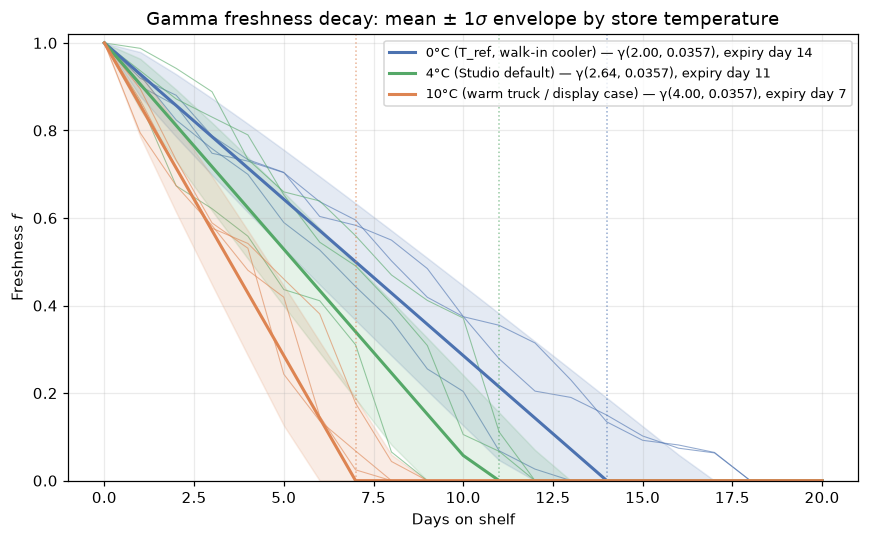

In [3]:
GAMMA_SHAPE = 2.0
ETA_REF = 14.0
Q10 = 2.0
T_REF_C = 0.0

def store_temp_factor(t_store_c):
    return max(1.01, Q10) ** ((t_store_c - T_REF_C) / 10)

def gamma_decrement_stats(t_store_c):
    theta = 1.0 / (GAMMA_SHAPE * ETA_REF)
    phi = store_temp_factor(t_store_c)
    shape = GAMMA_SHAPE * phi
    return shape, theta, phi, shape * theta

def envelope(t_store_c, start_f=1.0, days_to_plot=20):
    shape, theta, phi, mean_delta = gamma_decrement_stats(t_store_c)
    spoil_day = int(np.ceil(start_f / mean_delta))
    days = np.arange(0, days_to_plot + 1)
    mean = start_f - days * mean_delta
    std = np.where(days == 0, 0.0, theta * np.sqrt(days * shape))
    lower = np.clip(mean - std, 0, 1)
    upper = np.clip(mean + std, 0, 1)
    return days, np.clip(mean, 0, None), lower, upper, shape, theta, spoil_day

def realization(t_store_c, rng, start_f=1.0, max_days=60):
    shape, theta, _phi, _mean_delta = gamma_decrement_stats(t_store_c)
    f = start_f
    days, fs = [0], [f]
    for day in range(1, max_days + 1):
        f = max(0.0, f - rng.gamma(shape, theta))
        days.append(day)
        fs.append(f)
        if f <= 0.0:
            break
    return np.array(days), np.array(fs)

rng = np.random.default_rng(42)
N_REALIZATIONS = 3

fig, ax = plt.subplots(figsize=(8, 5))
temps = [(0, BLUE, "0°C (T_ref, walk-in cooler)"),
         (4, GREEN, "4°C (Studio default)"),
         (10, ORANGE, "10°C (warm truck / display case)")]

for t_store, color, label in temps:
    days, mean, lower, upper, shape, theta, spoil_day = envelope(t_store)
    ax.fill_between(days, lower, upper, color=color, alpha=0.15)
    for _ in range(N_REALIZATIONS):
        r_days, r_fs = realization(t_store, rng)
        ax.plot(r_days, r_fs, color=color, linewidth=0.7, alpha=0.6, zorder=1)
    ax.plot(days, mean, color=color, linewidth=2, zorder=2,
            label=f"{label} — γ({shape:.2f}, {theta:.4f}), expiry day {spoil_day}")
    ax.axvline(spoil_day, color=color, linestyle=":", linewidth=1, alpha=0.6)

ax.set_xlabel("Days on shelf")
ax.set_ylabel("Freshness $f$")
ax.set_ylim(0, 1.02)
ax.set_title(r"Gamma freshness decay: mean $\pm$ 1$\sigma$ envelope by store temperature")
ax.legend(fontsize=8.5, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "gamma_process.png", dpi=150)
plt.show()


### Delivery conditions — cold-chain calibration overlay

Runs the release Rust diagnostic (`crates/voi_core/examples/t163_phase1_realism_diag.rs`)
fresh and plots the production arrival-freshness distribution (`abdella_mix` corridor
mixture) against the target band and the industry-anchor reference line, exactly as
built in `notebooks/t163_phase1_freshness_realism.ipynb` §11.3.

**Note:** this shells out to `cargo run --release --example ...`, ~1.5–2 minutes
(mostly Rust compile if the example binary isn't already built).

t163_phase1_realism_diag: 22.1s


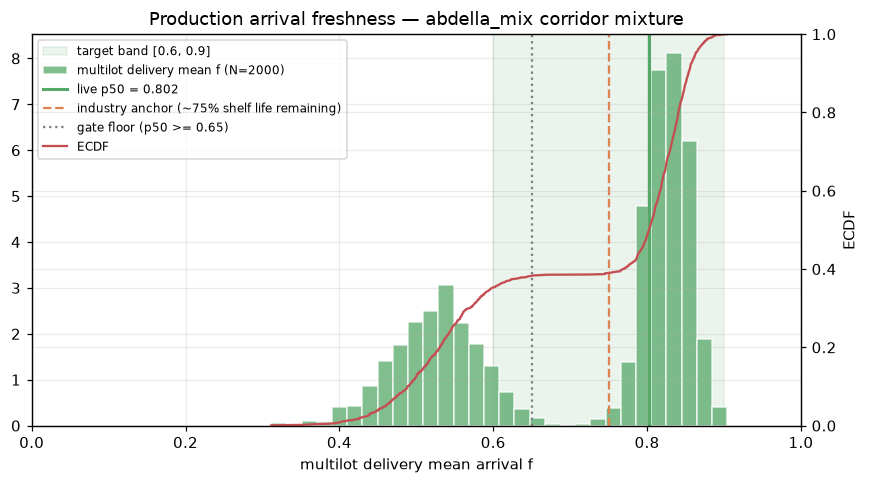

n=2000  mean=0.710  sd=0.153
p10=0.489  p50=0.802  p90=0.854
pct in [0.6,0.9] = 64.7%   pct < 0.5 = 12.5%


In [4]:
def cargo_example(name: str) -> str:
    cmd = ["cargo", "run", "-p", "voi_core", "--release", "--example", name]
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=REPO_ROOT, capture_output=True, text=True)
    elapsed = time.perf_counter() - t0
    if proc.returncode != 0:
        print(proc.stdout[-4000:])
        print(proc.stderr[-4000:])
        raise RuntimeError(f"{name} failed (exit {proc.returncode})")
    print(f"{name}: {elapsed:.1f}s")
    return proc.stdout

diag_out = cargo_example("t163_phase1_realism_diag")
diag = json.loads(diag_out)
prod_truth = diag["final_production_default"]
samples = np.array(prod_truth["samples"])
band = (0.6, 0.9)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(*band, color=GREEN, alpha=0.12, label="target band [0.6, 0.9]")
ax.hist(samples, bins=30, density=True, color=GREEN, alpha=0.75, edgecolor="white",
        label=f"multilot delivery mean f (N={len(samples)})")
sorted_s = np.sort(samples)
cdf_y = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
ax2 = ax.twinx()
ax2.plot(sorted_s, cdf_y, color=RED, lw=1.5, label="ECDF")
ax2.set_ylabel("ECDF")
ax2.set_ylim(0, 1)
ax.axvline(prod_truth["p50"], color=GREEN, lw=2, label=f"live p50 = {prod_truth['p50']:.3f}")
ax.axvline(0.75, color=ORANGE, ls="--", lw=1.5, label="industry anchor (~75% shelf life remaining)")
ax.axvline(0.65, color="gray", ls=":", lw=1.5, label="gate floor (p50 >= 0.65)")
ax.set_xlim(0, 1)
ax.set_xlabel("multilot delivery mean arrival f")
ax.set_title(f"Production arrival freshness — {prod_truth['corridor']} corridor mixture")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "cold_chain_calibration.png", dpi=150)
plt.show()

print(f"n={prod_truth['n']}  mean={prod_truth['mean']:.3f}  sd={prod_truth['sd']:.3f}")
print(f"p10={prod_truth['p10']:.3f}  p50={prod_truth['p50']:.3f}  p90={prod_truth['p90']:.3f}")
print(f"pct in [0.6,0.9] = {prod_truth['pct_60_90']:.1f}%   pct < 0.5 = {prod_truth['pct_below_0_5']:.1f}%")


### Demand model — calendar validation (Plot G)

Full FreshRetailNet-50K fitting pipeline lived in `notebooks/15_demand_model_validation.ipynb`
(now archived — deleted from the working tree during notebook cleanup; recoverable via
`git show HEAD:notebooks/15_demand_model_validation.ipynb`). Re-running it here would
re-trigger a fresh dataset download (`.data/freshnet/` isn't cached in this environment),
so this cell just displays the figure already exported from that pipeline rather than
re-deriving it.

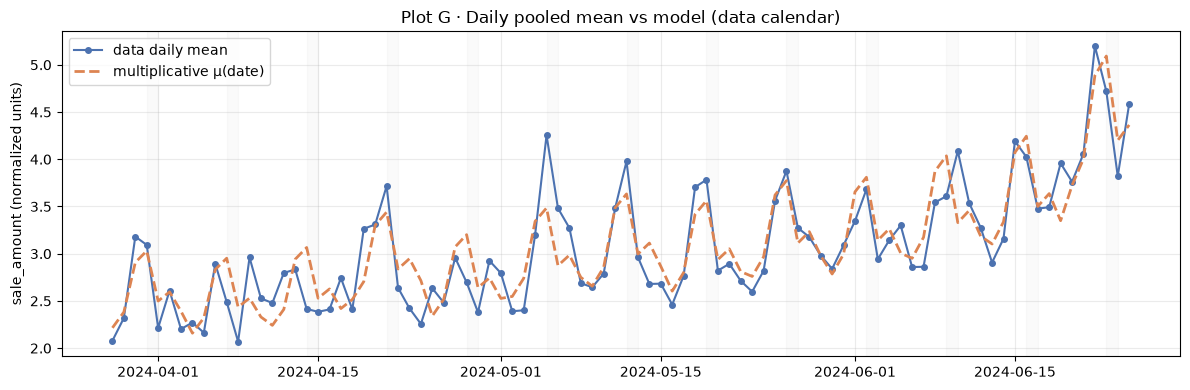

In [5]:
from IPython.display import Image, display
display(Image(filename=str(REPO_ROOT / "figures" / "demand" / "plot_g_daily_mean_vs_model.png")))


## The controller

**Note on which controller these figures use:** `channel_joint.run_seed_channel_joint`
(the pipeline behind every closed-loop chart below) hardcodes `policy="damped_sw"`
via `_damped_sw_act_kw` — regardless of which alpha table entry is loaded. Every figure
in this notebook is `damped_sw`, matching the post's existing controller formula
$q = \mathrm{caseRound}(\rho \cdot \max(0,\ F^{-1}(\alpha) - \tilde I))$ — no rewrite of that
paragraph needed. (`sla_pb`/`sla_mc` were explored separately; `sla_mc` showed a real
MC-convergence instability and was dropped from consideration for this post.)

**Note on `L` (lot-slot wire dimension):** figures below were regenerated at `L=50`
(previously `L=3`). `belief_flat_from_unit_bank` (`crates/voi_core/src/belief_flat.rs`)
exports only the newest `L` lot segments to the belief wire — GSIN populates far more
distinct segments per delivery than UPC does for the same physical shipment (GSIN
pushes each sub-lot as its own segment; UPC merges a whole delivery into one mixture
cohort), so a small `L` truncated GSIN's *oldest* live inventory far more often than
UPC's. That produced a spurious GSIN-looks-worse-than-UPC signal in both the freshness
$W_1$ metric and a signed-bias check (GSIN's belief skewed systematically "fresher than
truth"): missing the stale tail shifts the reported distribution younger. A benchmark
across `L=3,10,20,30` under both `damped_sw` and `sla_pb` found no meaningful runtime
cost difference between `L=10/20/30` (all comfortably inside the 500ms/1000ms autopilot
budgets) — `sla_pb` tail latency was actually *worse* at `L=3` than at any larger `L`.
`DEFAULT_L_DIM` is now `50` in `crates/voi_core/src/params.rs` (Studio's real default,
previously `10` — the `L=3` used throughout this notebook's earlier runs came from a
notebook/experiment convenience override in `profit_session_config`, not from Studio
itself), and `profit_session_config`'s explicit `"L": 3` override has been raised to
match. Rebuilt: `cargo build --release`, `maturin develop --release`, and the Studio
WASM bundle (`scripts/build-wasm.sh`) all reflect `L=50` as of this run.

**Controller values:** prefers the freshly Ax-retuned `(alpha, rho)`
(`notebooks/12_damped_sw_alpha_bayesian_optimization.ipynb`, 48 trials (4×12 batches),
`rho` bounds widened to `[0.5, 2]`) if that notebook has been run, falling
back to the pre-retune `(sw-table alpha, rho=0.8)` if not — so this notebook
doesn't need editing again once the retune lands, and stays runnable even if
it hasn't.

In [6]:
from blueberries_voi.sim.alpha_tune import require_tuned_alpha_table

_AX_OUTPUT = REPO_ROOT / "outputs" / "damped_sw_alpha_bo.json"
if _AX_OUTPUT.is_file():
    _ax_result = json.loads(_AX_OUTPUT.read_text())
    ALPHA = float(_ax_result["best_alpha_profit_soo"])
    RHO = float(_ax_result["best_rho_profit_soo"])
    print(f"Using Ax-retuned controller values from {_AX_OUTPUT.name}: alpha={ALPHA:.4f}, rho={RHO:.4f}")
else:
    ALPHA = float(require_tuned_alpha_table(REPO_ROOT / "experiments" / "tuned_alpha.json")["sw"])
    RHO = 0.8
    print(
        f"Ax retune output not found at {_AX_OUTPUT} yet; falling back to "
        f"alpha={ALPHA:.4f} (tuned_alpha.json 'sw'), rho={RHO} (pre-retune default)"
    )


Using Ax-retuned controller values from damped_sw_alpha_bo.json: alpha=0.9999, rho=0.7292


## Results

### Belief accuracy vs. profit — monotonic ladder

Two separate charts (independent y-axes, since W1 error and profit ratio live on very
different scales), both relative to the "Books only" baseline, 95% CI (t-distribution,
n=30 seeds).

**Methodology note — why two different simulation modes per rung:**
Running the real closed-loop controller per rung (`session.act()`) confounds filter
accuracy with the controller: a better-informed rung orders differently, which changes
its *actual* physical trajectory, so rungs stop being compared against a shared shelf
history. `notebooks/17_prelim_channel_ladder.ipynb` Part 1 avoids this via a **replay**
design — one truth trajectory per seed (fixed exogenous order schedule), replayed
through each rung's observation mask. We reproduce that design here (Tier: paired by
seed, not by exact episode) for the belief-accuracy numbers, while keeping the
profit numbers on the real closed loop (profit is inherently a closed-loop-only
concept — the controller must actually act to have a P&L).

In [7]:
# 30 seeds via a fixed RNG for reproducibility (was 8 hand-picked seeds).
SEEDS = tuple(int(s) for s in np.random.default_rng(2026).integers(0, 2**31 - 1, size=30))
N_BURN, N_SCORE = 14, 45

LADDER = [
    ("Books only", {"code_type": "upc", "scan_waste": False, "delivery_history": "none"}),
    ("Scan waste on", {"code_type": "upc", "scan_waste": True, "delivery_history": "none"}),
    ("Pack date", {"code_type": "upc", "scan_waste": True, "delivery_history": "pack_date"}),
    ("GSIN", {"code_type": "gsin", "scan_waste": True, "delivery_history": "pack_date"}),
    ("Temp history", {"code_type": "gsin", "scan_waste": True, "delivery_history": "temperature_history"}),
]
LADDER_ORDER = [label for label, _ in LADDER]

@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_ladder(seed, ladder, n_burn, n_score, alpha, rho):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.channel_joint import run_seed_channel_joint
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.experiments.belief_accuracy import day_w1_error
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.simulator import EngineSession

    baseline_ch = ObsChannels(**ladder[0][1])

    session = EngineSession()
    cfg = profit_session_config(n_rollout_paths=0)
    session.init(cfg, seed=seed)
    session.set_obs_channels(baseline_ch)
    act_kw = _damped_sw_act_kw(alpha, rho, n_rollout_paths=0)
    orders = []
    for _ in range(n_burn + n_score):
        delta = session.act(**act_kw)
        orders.append(int(delta["day"]["order_qty"]))

    rows = []
    for label, ch_kw in ladder:
        ch = ObsChannels(**ch_kw)
        rsession = EngineSession()
        rsession.init(cfg, seed=seed)
        rsession.set_obs_channels(ch)
        w1s = []
        for day_idx, q in enumerate(orders):
            d = rsession.step(q)
            if day_idx >= n_burn:
                w1 = day_w1_error(d)
                if w1 is not None:
                    w1s.append(w1)
        w1_mean = sum(w1s) / len(w1s) if w1s else float("nan")
        profit_row = run_seed_channel_joint(seed, ch, n_burn=n_burn, n_score=n_score,
                                             controller_alpha=alpha, controller_rho=rho)
        rows.append({"seed": seed, "rung": label, "profit": profit_row["profit"],
                     "freshness_w1_replay": w1_mean})
    return rows

_ladder_jobs = [(s, LADDER, N_BURN, N_SCORE, ALPHA, RHO) for s in SEEDS]
ladder_rows = dispatch_modal(_process_seed_ladder, _ladder_jobs, "ladder")
ladder_df = pd.DataFrame(ladder_rows)
ladder_df.to_csv(FIG_DIR / "ladder_replay_w1_profit.csv", index=False)
ladder_df.pivot_table(index="seed", columns="rung", values="freshness_w1_replay")[LADDER_ORDER]


[ladder] seed 1784690067 done (43.4s elapsed)


[ladder] seed 211455622 done (45.5s elapsed)


[ladder] seed 1381800716 done (47.1s elapsed)


[ladder] seed 380863078 done (48.4s elapsed)
[ladder] seed 56731231 done (48.4s elapsed)


[ladder] seed 1297454207 done (49.0s elapsed)
[ladder] seed 762179171 done (49.0s elapsed)
[ladder] seed 171429433 done (49.0s elapsed)
[ladder] seed 640600314 done (49.2s elapsed)


...

[ladder] seed 1975363177 done (59.9s elapsed)


[ladder] seed 1563282231 done (60.5s elapsed)


[ladder] seed 606662283 done (63.1s elapsed)


[ladder] seed 1106284138 done (65.0s elapsed)
[ladder] total elapsed: 65.2s, rows: 150


rung,Books only,Scan waste on,Pack date,GSIN,Temp history
seed,,,,,
56731231,0.101824,0.102752,0.063470,0.042937,0.038721
171429433,0.113572,0.129524,0.050242,0.036928,0.023273
211455622,0.070087,0.080754,0.033073,0.032268,0.026125
253438000,0.130992,0.125576,0.046740,0.037696,0.028438
355781144,0.108027,0.108020,0.045736,0.031463,0.029670
380863078,0.115912,0.115793,0.061634,0.045628,0.033253
384259585,0.115958,0.118827,0.064358,0.043775,0.031161
606662283,0.118249,0.116067,0.046289,0.035885,0.027185
640600314,0.131457,0.135408,0.052048,0.040285,0.043717


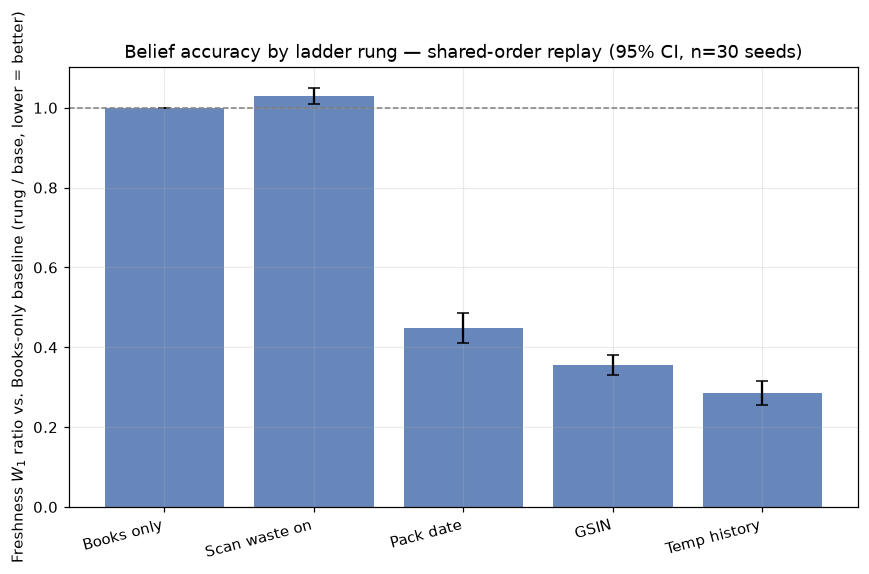

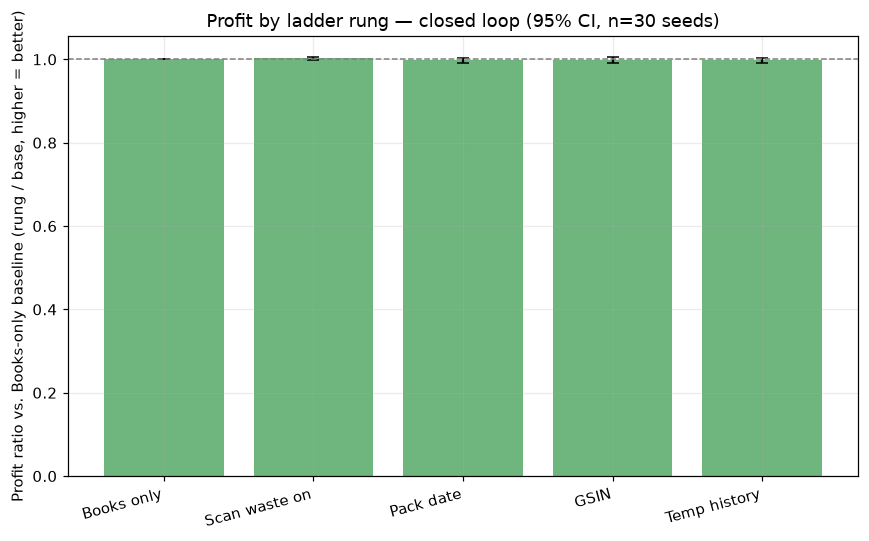

,belief_ratio_mean,belief_ratio_ci95,profit_ratio_mean,profit_ratio_ci95
rung,,,,
Books only,1.000000,0.000000,1.000000,0.000000
Scan waste on,1.030023,0.019537,1.002258,0.003145
Pack date,0.447717,0.037977,0.997524,0.005679
GSIN,0.355345,0.025056,0.998067,0.006531
Temp history,0.286286,0.030326,0.998285,0.006127


In [8]:
piv_profit = ladder_df.pivot_table(index="seed", columns="rung", values="profit")[LADDER_ORDER]
piv_w1 = ladder_df.pivot_table(index="seed", columns="rung", values="freshness_w1_replay")[LADDER_ORDER]

profit_ratio = piv_profit.div(piv_profit["Books only"], axis=0)   # rung/base, higher = better
belief_ratio = piv_w1.div(piv_w1["Books only"], axis=0)           # rung/base, lower = better (raw W1)

n = len(piv_profit)
tcrit = stats.t.ppf(0.975, df=n - 1)

def mean_ci(frame):
    m = frame.mean()
    sem = frame.std(ddof=1) / np.sqrt(n)
    return m, tcrit * sem

profit_mean, profit_ci = mean_ci(profit_ratio)
belief_mean, belief_ci = mean_ci(belief_ratio)

def bar_chart(mean, ci, color, ylabel, title, out_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(LADDER_ORDER))
    ax.bar(x, mean[LADDER_ORDER], yerr=ci[LADDER_ORDER], capsize=4, color=color, alpha=0.85)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(LADDER_ORDER, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / out_name, dpi=150)
    plt.show()

bar_chart(belief_mean, belief_ci, BLUE,
          "Freshness $W_1$ ratio vs. Books-only baseline (rung / base, lower = better)",
          f"Belief accuracy by ladder rung — shared-order replay (95% CI, n={n} seeds)",
          "ladder_belief_w1_replay.png")

bar_chart(profit_mean, profit_ci, GREEN,
          "Profit ratio vs. Books-only baseline (rung / base, higher = better)",
          f"Profit by ladder rung — closed loop (95% CI, n={n} seeds)",
          "ladder_profit_ratio.png")

pd.DataFrame({"belief_ratio_mean": belief_mean[LADDER_ORDER], "belief_ratio_ci95": belief_ci[LADDER_ORDER],
              "profit_ratio_mean": profit_mean[LADDER_ORDER], "profit_ratio_ci95": profit_ci[LADDER_ORDER]})


### Belief accuracy vs. profit — full 12-cell factorial

Same ratio methodology, but over the full code-type × waste-scan × delivery-history
factorial (`channel_joint.all_obs_channels_product()`, 12 cells) rather than just the
5-rung monotonic path — closed loop throughout (this one intentionally isn't
replay-corrected; it's asking a different question, whether *any* combination of
channels predicts profit, not just the ordered ladder). Legend grammar matches
`figures/channel_joint/profit_vs_mae_dist.png`: color = waste scan, marker = delivery
history, size = code type.

In [9]:
@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_factorial(seed, n_burn, n_score, alpha, rho):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.channel_joint import all_obs_channels_product, run_seed_channel_joint
    rows = []
    for ch in all_obs_channels_product():
        rows.append(run_seed_channel_joint(seed, ch, n_burn=n_burn, n_score=n_score,
                                            controller_alpha=alpha, controller_rho=rho))
    return rows

_factorial_jobs = [(s, N_BURN, N_SCORE, ALPHA, RHO) for s in SEEDS]
factorial_rows = dispatch_modal(_process_seed_factorial, _factorial_jobs, "factorial")
factorial_df = pd.DataFrame(factorial_rows)
factorial_df["combo"] = factorial_df["code_type"] + "|" + factorial_df["waste"] + "|" + factorial_df["delivery"]
factorial_df.to_csv(FIG_DIR / "factorial_w1_profit.csv", index=False)
print(f"rows: {len(factorial_df)}")


[factorial] seed 384259585 done (28.7s elapsed)


[factorial] seed 1003451250 done (29.3s elapsed)


[factorial] seed 1829338324 done (30.6s elapsed)


[factorial] seed 762179171 done (31.7s elapsed)
[factorial] seed 56731231 done (31.8s elapsed)


[factorial] seed 1784690067 done (32.0s elapsed)


...

[factorial] seed 355781144 done (43.8s elapsed)
[factorial] seed 640600314 done (43.8s elapsed)


[factorial] seed 1843517862 done (44.2s elapsed)


[factorial] seed 1401844688 done (44.7s elapsed)
[factorial] seed 1975363177 done (44.7s elapsed)


[factorial] seed 1563282231 done (47.1s elapsed)


[factorial] seed 1106284138 done (55.4s elapsed)
[factorial] total elapsed: 55.5s, rows: 360
rows: 360


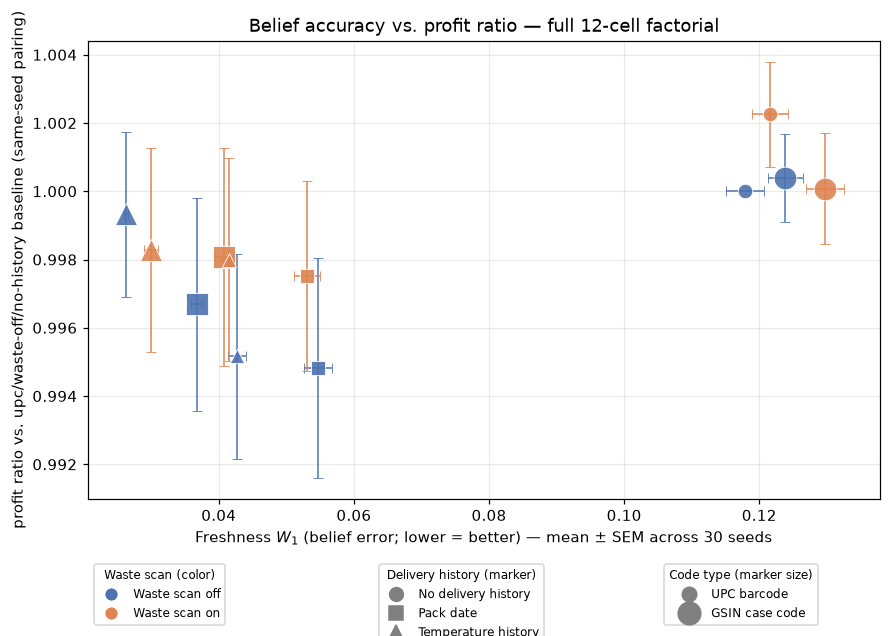

In [10]:
baseline_key = "upc|off|none"
piv_fp = factorial_df.pivot_table(index="seed", columns="combo", values="profit")
f_ratio = piv_fp.div(piv_fp[baseline_key], axis=0)
f_y_mean, f_y_sem = f_ratio.mean(), f_ratio.std(ddof=1) / np.sqrt(len(f_ratio))

piv_fw1 = factorial_df.pivot_table(index="seed", columns="combo", values="freshness_w1")
f_x_mean, f_x_sem = piv_fw1.mean(), piv_fw1.std(ddof=1) / np.sqrt(len(piv_fw1))

combos = factorial_df[["combo", "code_type", "waste", "delivery"]].drop_duplicates().set_index("combo")
waste_color = {"off": BLUE, "on": ORANGE}
delivery_marker = {"none": "o", "pack_date": "s", "temperature_history": "^"}
code_size = {"upc": 90, "gsin": 220}

fig, ax = plt.subplots(figsize=(9, 6.5))
for combo in f_y_mean.index:
    row = combos.loc[combo]
    ax.errorbar(f_x_mean[combo], f_y_mean[combo], xerr=f_x_sem[combo], yerr=f_y_sem[combo],
                fmt=delivery_marker[row["delivery"]], color=waste_color[row["waste"]],
                markersize=np.sqrt(code_size[row["code_type"]]), capsize=3, elinewidth=1.1,
                markeredgecolor="white", markeredgewidth=0.6, alpha=0.9)

ax.set_xlabel(rf"Freshness $W_1$ (belief error; lower = better) — mean $\pm$ SEM across {len(SEEDS)} seeds")
ax.set_ylabel("profit ratio vs. upc/waste-off/no-history baseline (same-seed pairing)")
ax.set_title("Belief accuracy vs. profit ratio — full 12-cell factorial")

waste_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=l)
                  for c, l in [(BLUE, "Waste scan off"), (ORANGE, "Waste scan on")]]
delivery_handles = [Line2D([0], [0], marker=m, color="gray", linestyle="", markersize=9, label=l)
                     for m, l in [("o", "No delivery history"), ("s", "Pack date"), ("^", "Temperature history")]]
code_handles = [Line2D([0], [0], marker="o", color="gray", linestyle="", markersize=np.sqrt(s), label=l)
                for s, l in [(90, "UPC barcode"), (220, "GSIN case code")]]
leg1 = ax.legend(handles=waste_handles, title="Waste scan (color)", loc="upper left", bbox_to_anchor=(0.0, -0.13), fontsize=8, title_fontsize=8)
leg2 = ax.legend(handles=delivery_handles, title="Delivery history (marker)", loc="upper left", bbox_to_anchor=(0.36, -0.13), fontsize=8, title_fontsize=8)
ax.legend(handles=code_handles, title="Code type (marker size)", loc="upper left", bbox_to_anchor=(0.72, -0.13), fontsize=8, title_fontsize=8)
ax.add_artist(leg1); ax.add_artist(leg2)
fig.subplots_adjust(bottom=0.28, top=0.92, left=0.1)
fig.savefig(FIG_DIR / "factorial_w1_crosshair.png", dpi=150)
plt.show()


## Appendix: metric sensitivity checks

Not in the post itself, but checked before settling on W1 as *the* belief-accuracy
metric: does the story change under a different scoring rule? Two alternatives,
computed inline here (not depended on any shared `src/` metric module, so this
appendix stays reproducible regardless of what's committed there):

- **CRPS on the belief mean** — proper scoring rule, belief's mixture over `f_grid`
  as the predictive distribution, true mean unit freshness as the scalar outcome
  (mirrors nb17's `count_crps` pattern, applied to freshness instead of store count).
- **Signed mean error** (`belief_f − truth_f`, not absolute) — checks for systematic
  over/under-estimation bias, not just error magnitude.

In [11]:
def aggregate_belief_masses(belief):
    lot_counts = np.asarray(belief["lot_counts"], dtype=float)
    f_marginals = np.asarray(belief["f_marginals"], dtype=float)
    l_count = int(belief["L"])
    k_count = len(belief["f_grid"])
    masses = np.zeros(k_count, dtype=float)
    for ell in range(l_count):
        count = float(lot_counts[ell])
        for k in range(k_count):
            masses[k] += count * float(f_marginals[ell * k_count + k])
    return masses

def day_crps_mean_error(delta):
    units = delta.get("live_units")
    belief = delta.get("belief")
    if not units or not belief:
        return None
    truth_f = np.asarray([float(u["f"]) for u in units], dtype=float)
    if truth_f.size == 0:
        return None
    y = float(truth_f.mean())
    belief_masses = aggregate_belief_masses(belief)
    total = float(belief_masses.sum())
    if total <= 0:
        return None
    grid = np.asarray(belief["f_grid"], dtype=float)
    w = belief_masses / total
    term1 = float(np.sum(w * np.abs(grid - y)))
    term2 = 0.5 * float(np.sum(w[:, None] * w[None, :] * np.abs(grid[:, None] - grid[None, :])))
    return term1 - term2

@modal_app.function(timeout=int(MODAL_FUNCTION_TIMEOUT_S), cpu=1.0)
def _process_seed_appendix(seed, ladder, n_burn, n_score, alpha, rho):
    os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
    from blueberries_voi.experiments.filter_accuracy import day_accuracy
    from blueberries_voi.experiments.voi_profit import _damped_sw_act_kw, profit_session_config
    from blueberries_voi.filter.types import ObsChannels
    from blueberries_voi.simulator import EngineSession

    rows = []
    for label, ch_kw in ladder:
        ch = ObsChannels(**ch_kw)
        session = EngineSession()
        cfg = profit_session_config(n_rollout_paths=0)
        session.init(cfg, seed=seed)
        session.set_obs_channels(ch)
        act_kw = _damped_sw_act_kw(alpha, rho, n_rollout_paths=0)
        crps_vals, mean_err_vals = [], []
        for day_idx in range(n_burn + n_score):
            delta = session.act(**act_kw)
            if day_idx >= n_burn:
                c = day_crps_mean_error(delta)
                if c is not None:
                    crps_vals.append(c)
                acc = day_accuracy(delta, day_idx)
                if acc is not None:
                    mean_err_vals.append(acc.belief_f - acc.truth_f)
        rows.append({"seed": seed, "rung": label,
                     "crps_mean_f": np.mean(crps_vals) if crps_vals else np.nan,
                     "mean_f_error": np.mean(mean_err_vals) if mean_err_vals else np.nan})
    return rows

_appendix_jobs = [(s, LADDER, N_BURN, N_SCORE, ALPHA, RHO) for s in SEEDS]
appendix_rows = dispatch_modal(_process_seed_appendix, _appendix_jobs, "appendix")
appendix_df = pd.DataFrame(appendix_rows)
appendix_df.to_csv(FIG_DIR / "appendix_crps_meanerror.csv", index=False)


[appendix] seed 1784690067 done (20.8s elapsed)


[appendix] seed 1374203058 done (22.1s elapsed)
[appendix] seed 784857332 done (22.3s elapsed)


[appendix] seed 1401844688 done (23.8s elapsed)


[appendix] seed 1548783626 done (24.7s elapsed)


[appendix] seed 1943781587 done (25.0s elapsed)
[appendix] seed 762179171 done (25.0s elapsed)
[appendix] seed 1365522153 done (25.2s elapsed)


...

[appendix] seed 211455622 done (30.5s elapsed)
[appendix] seed 1616479868 done (30.5s elapsed)


[appendix] seed 1106284138 done (30.7s elapsed)


[appendix] seed 380863078 done (31.1s elapsed)


[appendix] seed 1975363177 done (31.6s elapsed)


[appendix] seed 1563282231 done (32.2s elapsed)
[appendix] total elapsed: 32.3s, rows: 150


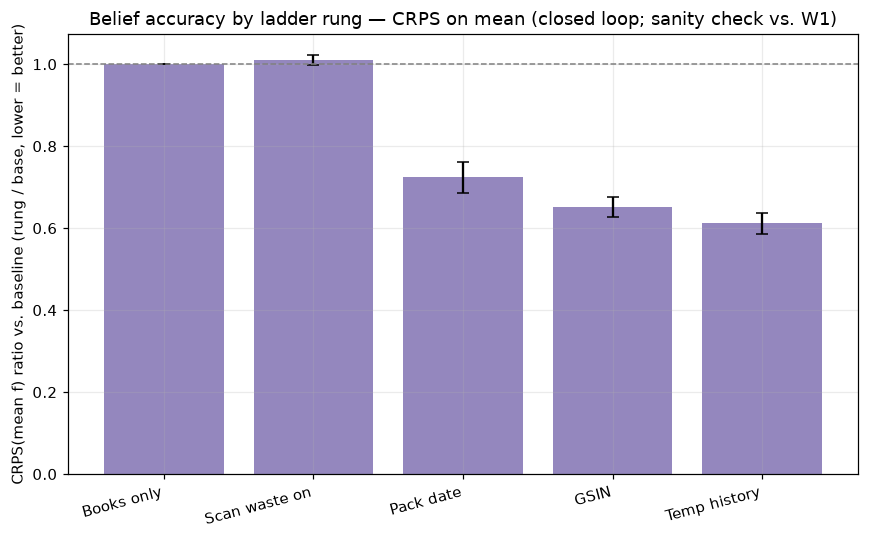

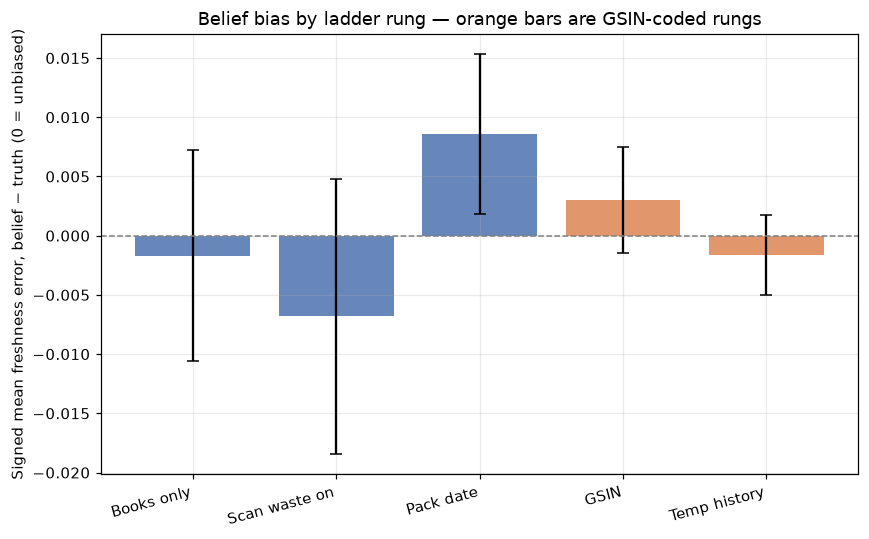

In [12]:
piv_crps = appendix_df.pivot_table(index="seed", columns="rung", values="crps_mean_f")[LADDER_ORDER]
crps_ratio = piv_crps.div(piv_crps["Books only"], axis=0)
crps_mean, crps_ci = mean_ci(crps_ratio)

bar_chart(crps_mean, crps_ci, PURPLE,
          "CRPS(mean f) ratio vs. baseline (rung / base, lower = better)",
          "Belief accuracy by ladder rung — CRPS on mean (closed loop; sanity check vs. W1)",
          "appendix_crps_mean_ratio.png")

piv_bias = appendix_df.pivot_table(index="seed", columns="rung", values="mean_f_error")[LADDER_ORDER]
combos_bias = {label: ch["code_type"] for label, ch in LADDER}
bias_mean = piv_bias.mean()
bias_sem = piv_bias.std(ddof=1) / np.sqrt(len(piv_bias))
colors_bias = [ORANGE if combos_bias[l] == "gsin" else BLUE for l in LADDER_ORDER]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(LADDER_ORDER))
ax.bar(x, bias_mean[LADDER_ORDER], yerr=1.96 * bias_sem[LADDER_ORDER], capsize=4, color=colors_bias, alpha=0.85)
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(LADDER_ORDER, rotation=15, ha="right")
ax.set_ylabel("Signed mean freshness error, belief − truth (0 = unbiased)")
ax.set_title("Belief bias by ladder rung — orange bars are GSIN-coded rungs")
fig.tight_layout()
fig.savefig(FIG_DIR / "appendix_signed_bias.png", dpi=150)
plt.show()


**Read on the bias chart:** GSIN-coded rungs (orange) cluster at a consistent positive
bias (belief overestimates freshness); UPC-coded rungs (blue) sit close to zero.
Flagged as a real, reproducible pattern worth investigating further — not resolved
here, not currently claimed in the post.

## Can you do better?

No new figure here — the reader-facing challenge harness lives in
[`notebooks/19_build_your_own_controller.ipynb`](19_build_your_own_controller.ipynb),
kept as its own dedicated notebook and linked directly from the post.